# Restaurant Agent With LLM And Gradio

In the previous notebook, our restaurant agent followed fixed Python rules.

Now we will build a similar restaurant agent, but one node will use an LLM.

Then we will make a small Gradio app so a user can type an order and get a response.

OpenAI is paid, so this notebook tries to use Groq first with `GROQ_API_KEY`. If you later add `OPENAI_API_KEY`, you can use OpenAI too.

## Big Picture In Easy Words

Imagine a restaurant.

A customer says: I want biryani.

The restaurant process is:

1. Waiter takes the order
2. Kitchen reads the order
3. Chef thinks about what to cook
4. Waiter replies to the customer

In our agent:

| Restaurant Thing | Agent Thing |
| --- | --- |
| Order paper | State |
| Waiter | Node |
| Chef thinking | LLM node |
| Path between workers | Edge |
| Full restaurant process | Graph |

## Free-Friendly LLM Choice

OpenAI works well, but it normally needs paid billing.

For learning, use one of these:

1. Groq API: good for this notebook. Add `GROQ_API_KEY` in `.env`.
2. Ollama: runs locally on your laptop, no API key, but you must install Ollama and download a model.
3. Gemini/Groq free tiers can change, so always check their current dashboard before depending on them.

This notebook uses Groq first because your environment already has `langchain-groq` installed.

## Step 1: Import Libraries

`dotenv` loads keys from `.env`.

`StateGraph`, `START`, and `END` build the LangGraph workflow.

`add_messages` keeps message history.

`ChatGroq` is the free-friendly LLM option here.

`ChatOpenAI` is optional if you have an OpenAI key.

`gradio` creates the web app.

In [1]:
import os
from typing import Annotated, TypedDict

import gradio as gr
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_groq import ChatGroq
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

## Step 2: Load API Keys

The `.env` file is like a private notebook for secret keys.

Never upload `.env` to GitHub.

For Groq, put this in `.env`:

`GROQ_API_KEY=your_key_here`

For OpenAI, put this in `.env` only if you want to use paid OpenAI:

`OPENAI_API_KEY=your_key_here`

In [2]:
load_dotenv()

groq_key = os.getenv("GROQ_API_KEY")
openai_key = os.getenv("OPENAI_API_KEY")

print("GROQ_API_KEY:", "set" if groq_key else "missing")
print("OPENAI_API_KEY:", "set" if openai_key else "missing")

GROQ_API_KEY: set
OPENAI_API_KEY: missing


## Step 3: Create The LLM

This function chooses which LLM to use.

First choice: Groq, because it is better for learning without OpenAI billing.

Second choice: OpenAI, only if you added an OpenAI key.

If no key exists, the notebook gives a clear message instead of confusing errors.

In [3]:
def create_llm():
    if os.getenv("GROQ_API_KEY"):
        print("Using Groq LLM")
        return ChatGroq(model="llama-3.1-8b-instant", temperature=0.3)

    if os.getenv("OPENAI_API_KEY"):
        print("Using OpenAI LLM")
        return ChatOpenAI(model="gpt-4o-mini", temperature=0.3)

    print("No LLM key found. Add GROQ_API_KEY in .env for the free-friendly option.")
    return None


llm = create_llm()

Using Groq LLM


## Step 4: Define State

State is the information bag that travels through the graph.

For the restaurant, state carries:

- `order`: what the customer wants
- `messages`: history of what happened
- `kitchen_plan`: the LLM answer from the chef node
- `final_response`: the final message shown to the customer

In [4]:
class LLRestaurantState(TypedDict, total=False):
    messages: Annotated[list, add_messages]
    order: str
    kitchen_plan: str
    final_response: str

## Step 5: Create Nodes

We will create three nodes.

1. `take_order`: receives the customer order
2. `chef_llm`: asks the LLM to think like a helpful restaurant chef
3. `serve_customer`: prepares the final response

Only `chef_llm` uses the LLM. The other nodes are simple Python.

In [5]:
def take_order(state: LLRestaurantState) -> LLRestaurantState:
    order = state.get("order", "biryani")
    print("1. Waiter received order:", order)

    return {
        "order": order,
        "messages": [f"Customer ordered: {order}"]
    }


def chef_llm(state: LLRestaurantState) -> LLRestaurantState:
    if llm is None:
        raise ValueError("Please add GROQ_API_KEY in .env, then restart the notebook kernel.")

    order = state["order"]
    print("2. Chef LLM is thinking about:", order)

    system_prompt = """
You are a friendly restaurant chef assistant.
Reply in very simple English.
Keep the answer short.
Tell the customer that the order is accepted and what will happen next.
"""

    user_prompt = f"Customer ordered: {order}. Create a short restaurant reply."

    response = llm.invoke([
        SystemMessage(content=system_prompt),
        HumanMessage(content=user_prompt)
    ])

    return {
        "kitchen_plan": response.content,
        "messages": [response]
    }


def serve_customer(state: LLRestaurantState) -> LLRestaurantState:
    print("3. Waiter is serving the LLM response")

    final_response = state["kitchen_plan"]

    return {
        "final_response": final_response,
        "messages": [f"Final response sent to customer: {final_response}"]
    }

## Step 6: Build The Graph

Now we connect the nodes with edges.

The flow is:

`START -> take_order -> chef_llm -> serve_customer -> END`

This is like a restaurant route:

Customer -> Waiter -> Chef -> Waiter -> Customer

In [6]:
llm_restaurant_builder = StateGraph(LLRestaurantState)

llm_restaurant_builder.add_node("take_order", take_order)
llm_restaurant_builder.add_node("chef_llm", chef_llm)
llm_restaurant_builder.add_node("serve_customer", serve_customer)

llm_restaurant_builder.add_edge(START, "take_order")
llm_restaurant_builder.add_edge("take_order", "chef_llm")
llm_restaurant_builder.add_edge("chef_llm", "serve_customer")
llm_restaurant_builder.add_edge("serve_customer", END)

llm_restaurant_graph = llm_restaurant_builder.compile()

## Step 7: Display The Graph

Run this cell to see the graph object or a small diagram.

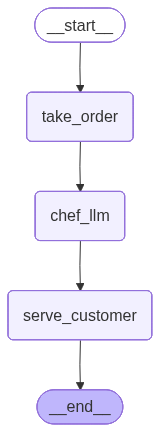

In [7]:
llm_restaurant_graph

## Step 8: Run The Agent Once

This cell sends one order to the agent.

If you do not have `GROQ_API_KEY` or `OPENAI_API_KEY`, this cell will ask you to add a key first.

In [8]:
result = llm_restaurant_graph.invoke({
    "order": "biryani",
    "messages": []
})

result["final_response"]

/Users/maria/Documents/Agentic-AI/venv/lib/python3.12/site-packages/langsmith/client.py:653: LangSmithMissingAPIKeyWarning: API key must be provided when using hosted LangSmith API
  warnings.warn(


1. Waiter received order: biryani
2. Chef LLM is thinking about: biryani
3. Waiter is serving the LLM response


'"Your biryani order is accepted. We will start cooking now. It will be ready in 20 minutes. We will call your name when it\'s ready."'

Failed to multipart ingest runs: langsmith.utils.LangSmithAuthError: Authentication failed for https://api.smith.langchain.com/runs/multipart. HTTPError('401 Client Error: Unauthorized for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Unauthorized"}\n')trace=019f37a3-4127-7a90-bf7b-4fe25aa98717,id=019f37a3-4127-7a90-bf7b-4fe25aa98717; trace=019f37a3-4127-7a90-bf7b-4fe25aa98717,id=019f37a3-416f-7c60-aa90-45ba16e88553; trace=019f37a3-4127-7a90-bf7b-4fe25aa98717,id=019f37a3-4171-7460-b223-67f3b3c076b8; trace=019f37a3-4127-7a90-bf7b-4fe25aa98717,id=019f37a3-4178-78f1-89cd-f804f64ba715; trace=019f37a3-4127-7a90-bf7b-4fe25aa98717,id=019f37a3-4317-7743-924c-fb6b6d601c9e


## Step 9: Create A Gradio App

Gradio makes a simple web app from a Python function.

The user types an order.

Our function sends that order into the LangGraph agent.

The agent returns the final LLM response.

In [9]:
def restaurant_agent_app(order: str) -> str:
    if not order.strip():
        return "Please enter an order, for example: biryani."

    try:
        result = llm_restaurant_graph.invoke({
            "order": order,
            "messages": []
        })
        return result["final_response"]
    except Exception as error:
        return f"Error: {error}"

## Step 10: Launch The Gradio App

Run this cell to start the app.

A local URL will appear below the cell.

Open that URL in your browser and type a restaurant order.

When you are done, stop the cell or interrupt the kernel.

In [ ]:
demo = gr.Interface(
    fn=restaurant_agent_app,
    inputs=gr.Textbox(label="Customer Order", placeholder="Example: I want chicken biryani"),
    outputs=gr.Textbox(label="Restaurant Agent Reply"),
    title="Restaurant LLM Agent",
    description="A simple LangGraph agent with one LLM node."
)

demo.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


/Users/maria/Documents/Agentic-AI/venv/lib/python3.12/site-packages/gradio/routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)


1. Waiter received order: i want chicken bryani
2. Chef LLM is thinking about: i want chicken bryani
3. Waiter is serving the LLM response


Failed to send compressed multipart ingest: langsmith.utils.LangSmithAuthError: Authentication failed for https://api.smith.langchain.com/runs/multipart. HTTPError('401 Client Error: Unauthorized for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Unauthorized"}\n')trace=019f37a3-c80b-7243-aaf2-e34cd2e33fa7,id=019f37a3-c80b-7243-aaf2-e34cd2e33fa7; trace=019f37a3-c80b-7243-aaf2-e34cd2e33fa7,id=019f37a3-c813-7220-b8e4-4234381384f3; trace=019f37a3-c80b-7243-aaf2-e34cd2e33fa7,id=019f37a3-c813-7220-b8e4-4234381384f3; trace=019f37a3-c80b-7243-aaf2-e34cd2e33fa7,id=019f37a3-c815-73d2-9488-0ef834aa3cf9; trace=019f37a3-c80b-7243-aaf2-e34cd2e33fa7,id=019f37a3-c817-7a13-8a5a-a1a09406dbae; trace=019f37a3-c80b-7243-aaf2-e34cd2e33fa7,id=019f37a3-c817-7a13-8a5a-a1a09406dbae; trace=019f37a3-c80b-7243-aaf2-e34cd2e33fa7,id=019f37a3-c815-73d2-9488-0ef834aa3cf9; trace=019f37a3-c80b-7243-aaf2-e34cd2e33fa7,id=019f37a3-c8e4-7793-94f3-f7d9fb93277c; trace=019f37a3-c80b-7243-aaf2-e34cd2e33fa7,id

1. Waiter received order: what is AI
2. Chef LLM is thinking about: what is AI
3. Waiter is serving the LLM response


...

1. Waiter received order: i want burger
2. Chef LLM is thinking about: i want burger
3. Waiter is serving the LLM response


Failed to send compressed multipart ingest: langsmith.utils.LangSmithAuthError: Authentication failed for https://api.smith.langchain.com/runs/multipart. HTTPError('401 Client Error: Unauthorized for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Unauthorized"}\n')trace=019f37a4-70b2-7b32-a488-f65c85344f2d,id=019f37a4-70b2-7b32-a488-f65c85344f2d; trace=019f37a4-70b2-7b32-a488-f65c85344f2d,id=019f37a4-70b6-72a0-a295-b91719bf2321; trace=019f37a4-70b2-7b32-a488-f65c85344f2d,id=019f37a4-70b6-72a0-a295-b91719bf2321; trace=019f37a4-70b2-7b32-a488-f65c85344f2d,id=019f37a4-70b7-7102-9679-41086af3273e; trace=019f37a4-70b2-7b32-a488-f65c85344f2d,id=019f37a4-70b8-7fc1-bb6d-8c94b072a2be; trace=019f37a4-70b2-7b32-a488-f65c85344f2d,id=019f37a4-70b8-7fc1-bb6d-8c94b072a2be; trace=019f37a4-70b2-7b32-a488-f65c85344f2d,id=019f37a4-70b7-7102-9679-41086af3273e; trace=019f37a4-70b2-7b32-a488-f65c85344f2d,id=019f37a4-7189-7333-b382-3fe1c234ee04; trace=019f37a4-70b2-7b32-a488-f65c85344f2d,id

1. Waiter received order: i want checikn bryani 
2. Chef LLM is thinking about: i want checikn bryani 
3. Waiter is serving the LLM response


Failed to send compressed multipart ingest: langsmith.utils.LangSmithAuthError: Authentication failed for https://api.smith.langchain.com/runs/multipart. HTTPError('401 Client Error: Unauthorized for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Unauthorized"}\n')trace=019f37a4-cfe4-7862-b711-7bd862ae6d8f,id=019f37a4-cfe4-7862-b711-7bd862ae6d8f; trace=019f37a4-cfe4-7862-b711-7bd862ae6d8f,id=019f37a4-cfeb-7602-bdbd-44eb331d6cd2; trace=019f37a4-cfe4-7862-b711-7bd862ae6d8f,id=019f37a4-cfeb-7602-bdbd-44eb331d6cd2; trace=019f37a4-cfe4-7862-b711-7bd862ae6d8f,id=019f37a4-cff0-7832-8724-5901d774c62a; trace=019f37a4-cfe4-7862-b711-7bd862ae6d8f,id=019f37a4-cff3-79a1-8569-72a4210089a6; trace=019f37a4-cfe4-7862-b711-7bd862ae6d8f,id=019f37a4-cff3-79a1-8569-72a4210089a6; trace=019f37a4-cfe4-7862-b711-7bd862ae6d8f,id=019f37a4-cff0-7832-8724-5901d774c62a; trace=019f37a4-cfe4-7862-b711-7bd862ae6d8f,id=019f37a4-d0ff-7591-b691-c41965ebf294; trace=019f37a4-cfe4-7862-b711-7bd862ae6d8f,id

Created dataset file at: .gradio/flagged/dataset1.csv


## What Did We Build?

We built a basic LLM agent.

The agent is not only one direct LLM call. It has a structure:

1. State carries the order
2. First node receives the order
3. LLM node thinks and creates a reply
4. Final node serves the reply
5. Gradio makes it usable as an app

This is the same idea as the restaurant example, but now the chef node can think using an LLM.